In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, permutations

def euclid_distance(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    takes two points p1, p2 as two ndarrays of length d (d: dimension) 
    and calculates the euclidean distance between the two points
    returns distance as float value
    """
    return np.sqrt(np.sum(np.square(p1 - p2)))

def tsp_length(nodes_array: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    
    :param nodes_array: (sorted) array of coordinates of the N nodes
    :type nodes_array: np.ndarray (N, d)
    :return: total traveling distance
    :rtype: float
    """
    # calculate the pairwise differences between two consecutive nodes, keep in mind to return to start
    differences = nodes_array - np.roll(nodes_array, shift=-1, axis=0)
    # calculate individual distances and sum up
    distances = np.sqrt(np.sum(np.square(differences), axis=1))
    return np.sum(distances)

def tsp_length_from_dist_matrix(distance_matrix: np.ndarray, permutation: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    given the distance matrix D and the current permutation
    
    :param distance_matrix: 2d array of distances of the node i to node j,
    (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
    :type distance_matrix: np.ndarray (N, N)
    :param permutation: 1d array of current permutation given as set of not repeating indices
    :type distance_matrix: np.ndarray (N)
    :return: total traveling distance
    :rtype: float
    """
    # sum distances between consecutive nodes (equation 3 in Cerny 1985)
    d = np.sum(distance_matrix[permutation[:-1], permutation[1:]])
    # add distance from last node back to first
    d += distance_matrix[permutation[-1], permutation[0]]
    return d

def polar_to_cartesian(r: float, theta: float) -> np.ndarray:
    """
    convert polar coordinates to cartesian coordinates
    
    :param r: radius
    :type r: float
    :param theta: angle in radians
    :type theta: float
    :return: cartesian coordinates as ndarray [x, y]
    :rtype: np.ndarray
    """
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def cartesian_to_polar(x: float, y: float) -> np.ndarray:
    """
    convert cartesian coordinates to polar coordinates
    
    :param x: x coordinate
    :type x: float
    :param y: y coordinate
    :type y: float
    :return: polar coordinates as ndarray [r, theta]
    :rtype: np.ndarray
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return np.column_stack([r, theta])



In [2]:
# define N nodes, uniformly spaced around a circle
N = 8
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# brute force TSP solution
# always start and end at node 0
# get all permutations of the nodes excluding the first one
node_indices = np.arange(N)
perms = permutations(node_indices)
tours = nodes[np.array([[0] + list(p) + [0] for p in perms])]
lengths = np.array([tsp_length(tour) for tour in tours])
min_index = np.argmin(lengths)
min_length = lengths[min_index]

print(f"Minimum traveling distance: {min_length:4f}")



Minimum traveling distance: 6.122935


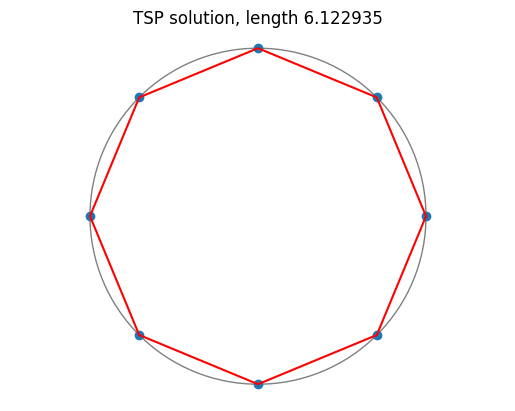

In [3]:
# plot results
plt.figure()
plt.title(f"TSP solution, length {min_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1])
plt.plot(tours[min_index][:, 0], tours[min_index][:, 1], 'r-')
plt.show()

want_a_lot_of_plots = False
if want_a_lot_of_plots:
    for tour in tours[::]:
        plt.figure()
        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        circle = plt.Circle((0, 0), R, color='gray', fill=False)
        plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1])
        plt.plot(tour[:, 0], tour[:, 1], 'b-', alpha=0.1)
    plt.show()

## Monte-Carlo simulating an approximative TSP result

In [4]:
# generating points
# define N nodes, uniformly spaced around a circle
N = 100
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# calculate the distance matrix D_{i,j} once
# D_{i,j} denotes the distance of node i to node j (note D_{i,j}^T = D_{j,i} = D_{i,j} and D_{i,i} = 0 ∀i)
# nodes shape: (N, 2)
differences = nodes[:, np.newaxis, :] - nodes[np.newaxis, :, :]  # shape: (N, N, 2)
D = np.sqrt(np.sum(differences**2, axis=-1))                     # shape: (N, N)
print('Fast slicing and broadcasting approach:', D)

Fast slicing and broadcasting approach: [[0.         0.06282152 0.12558104 ... 0.18821663 0.12558104 0.06282152]
 [0.06282152 0.         0.06282152 ... 0.25066647 0.18821663 0.12558104]
 [0.12558104 0.06282152 0.         ... 0.31286893 0.25066647 0.18821663]
 ...
 [0.18821663 0.25066647 0.31286893 ... 0.         0.06282152 0.12558104]
 [0.12558104 0.18821663 0.25066647 ... 0.06282152 0.         0.06282152]
 [0.06282152 0.12558104 0.18821663 ... 0.12558104 0.06282152 0.        ]]


In [5]:
# define parameters for the algorithm
temperatures = [0.1, 0.01, 0.001]  # starting temperature
repetitions = 10000  # number of times algorithm is repeated (better in the future find a convergance criteria)

In [6]:
# implement algorithm
# randomly generate starting permutation
starting_perm = np.random.permutation(N)
# print(starting_perm, min(starting_perm), max(starting_perm))

length_arr = []

current_perm = starting_perm.copy()
current_length = tsp_length_from_dist_matrix(D, current_perm)

temperature_step = 0  # for loading bar
for temperature in temperatures:
    for repetition in range(repetitions):
        for i in range(N):
            # sample j from 0 to N-1 with j=!i
            choices = np.arange(N)
            j = np.random.choice(choices[choices != i])

            # generate new permutation
            i_tilde, j_tilde = min(i,j), max(i,j)
            trial_perm = current_perm.copy()
            trial_perm[i_tilde : j_tilde + 1] = current_perm[i_tilde : j_tilde + 1][::-1]
            trial_perm[j_tilde + 1 :] = current_perm[j_tilde + 1 :]
            # calculate corresponding length
            trial_length = tsp_length_from_dist_matrix(D, trial_perm)

            length_arr.append(trial_length)

            # accept reject step
            if trial_length < current_length:
                current_perm = trial_perm.copy()
                current_length = trial_length
            else:
                x = np.random.rand()
                if x < np.exp((current_length - trial_length) / temperature):
                    current_perm = trial_perm.copy()
                    current_length = trial_length 
            
        # loading bar
        fraction = (temperature_step * repetitions + repetition) / (len(temperatures) * repetitions)
        bar_length = 40
        filled_length = int(bar_length * fraction)
        bar = '=' * filled_length + '-' * (bar_length - filled_length)
        print(f'\rAnnealing progress: |{bar}| {fraction:.2%} Complete (T={temperature})', end='', flush=True)           
    temperature_step += 1

Annealing progress: |----------------------------------------| 0.01% Complete (T=0.1)

Annealing progress: |=======================================-| 100.00% Complete (T=0.001)

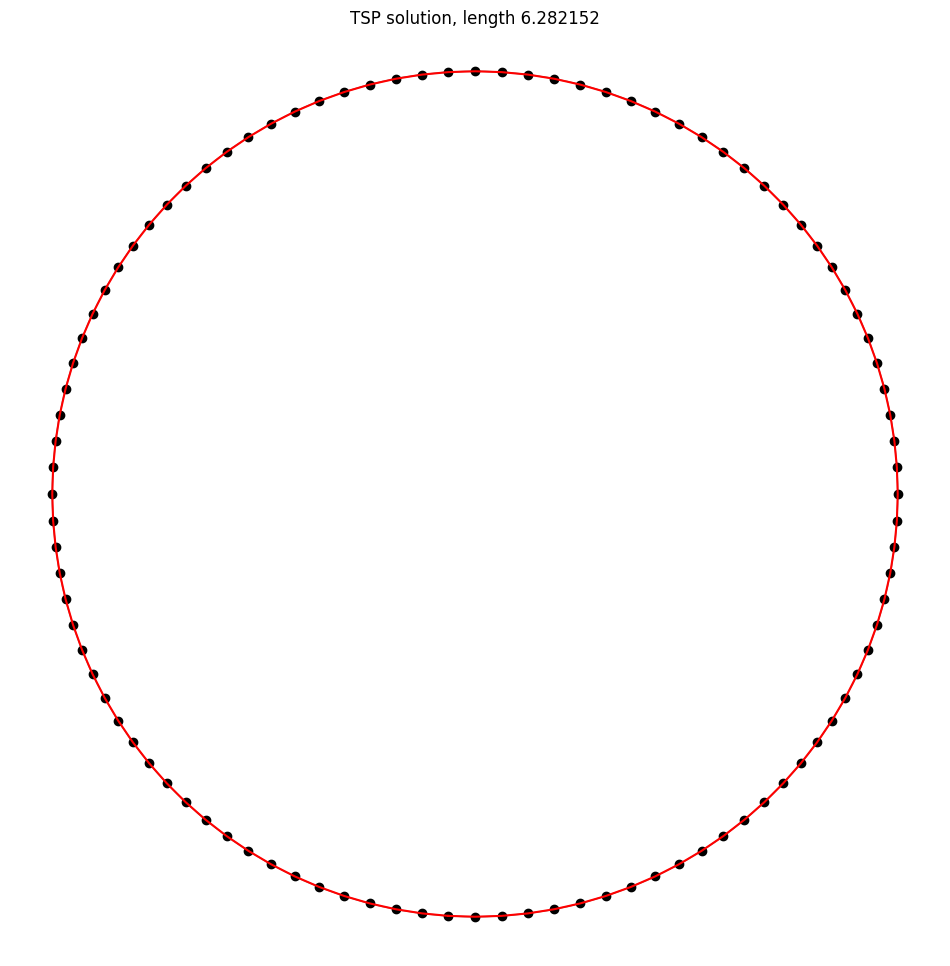

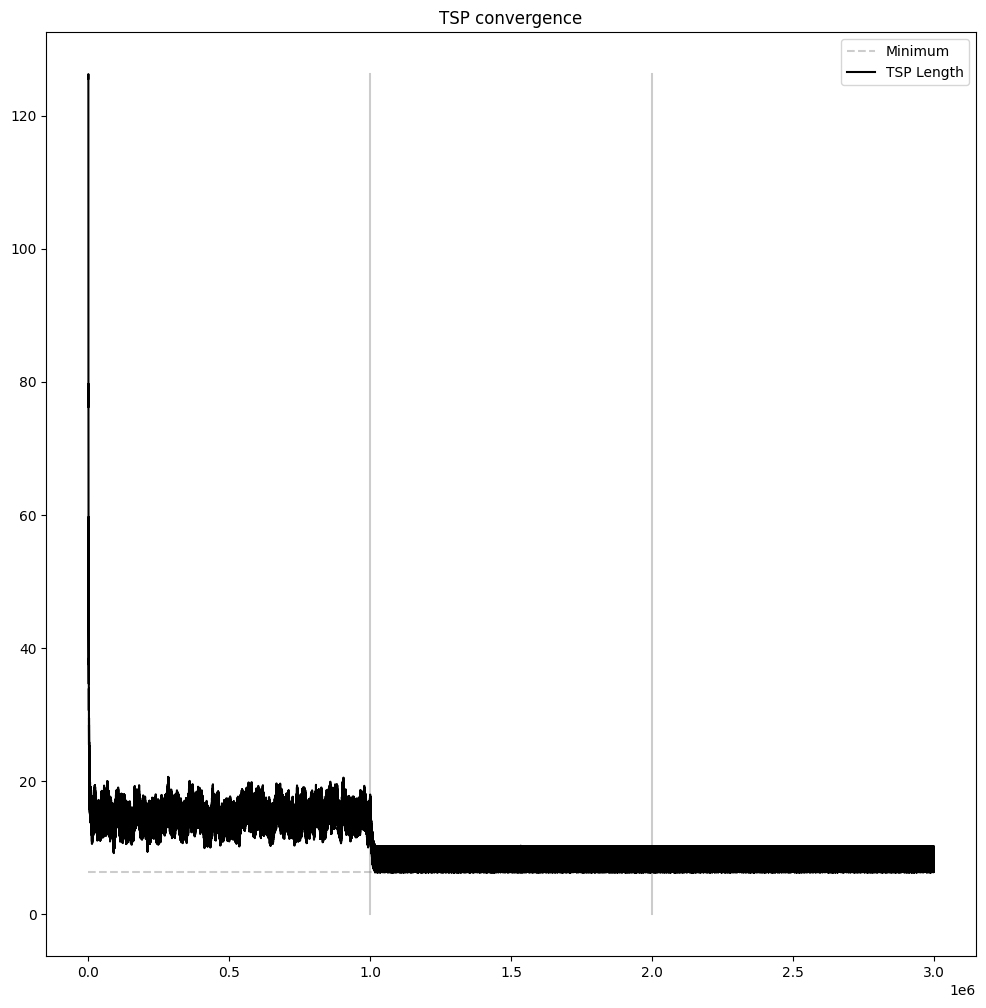

In [7]:
# plot the tour
plt.figure(figsize=(12,12))
plt.title(f"TSP solution, length {current_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1], color='black')
tour = np.append(current_perm, current_perm[0])  # close tour
plt.plot(nodes[tour, 0], nodes[tour, 1], color='red')
plt.savefig('simulated_annealing_final_tour.pdf')
plt.show()

plt.figure(figsize=(12,12))
plt.title(f"TSP convergence")
plt.plot([0, len(length_arr)], [2 * np.pi, 2 * np.pi], '--', alpha = 0.4, color='grey', label='Minimum')
for i in range(1, len(temperatures)):
    plt.plot([i * N * repetitions, i * N * repetitions], [0, max(length_arr)], alpha = 0.4, color='grey')
plt.plot(length_arr, color='black', label='TSP Length')
plt.legend()
plt.savefig('tsp_sim_annealing_convergence.pdf')
plt.show()